# BZAN 6357 — Final Group Project
## Car Insurance Cross-Sell Prediction
**Course:** BZAN 6357  
**Dataset:** `bzan6357_insurance_3_TRAINING.csv` / `bzan6357_insurance_3_SCORE.csv` 

**Group member :** Khiem Huol, Jeremy Baccam

## Introduction

This project addresses a real-world cross-selling problem for a large international insurance company. The company already has relationships with medical insurance policyholders who are believed to be vehicle owners. The business objective is to identify which of those customers are most likely to purchase a car insurance policy when contacted by a sales representative — allowing the company to prioritize outreach and improve conversion rates.

## Project Objective

Build and evaluate a range of supervised machine-learning classification models to **predict the probability that each customer in the Score dataset will purchase** the cross-sold car insurance product. Final classifications (purchased / no purchase) are derived from these probabilities using an optimized decision threshold.

**Evaluation metrics:** Model performance is evaluated using:

- ROC AUC — measures how well the model ranks purchasers above non-purchasers across all thresholds.
- F-1 Score — balances precision and recall for classification decisions, especially important under class imbalance.

---

## Table of Contents
1. [Data Preparation](#1-data-preparation)
   - 1.1 Library Imports
   - 1.2 Load Data
   - 1.3 Data Quality Checks
2. [Exploratory Data Analysis (EDA)](#2-exploratory-data-analysis)
   - 2.1 Target Variable Distribution
   - 2.2 Purchase Rate by Categorical Features
   - 2.3 Regional Variation
   - 2.4 Numerical Feature Distributions
   - 2.5 Correlation Analysis
3. [Feature Engineering & Preprocessing](#3-feature-engineering--preprocessing)
   - 3.1 Feature Engineering Function
   - 3.2 Target Encoding for High-Cardinality Columns
   - 3.3 Final Feature Selection & Train/Test Split
   - 3.4 Scaling
4. [Model Development & Evaluation](#4-model-development--evaluation)
   - 4.1 Baseline Models with 10-Fold CV Grid Search
   - 4.2 Model Comparison
   - 4.3 Best Single Model — LightGBM
   - 4.4 Optimized Weight Blending
   - 4.5 Ensemble Construction
   - 4.7 Performance Comparison: Single Models vs. Ensemble Approach
5. [Final Model & Score Dataset](#5-final-model--score-dataset)
   - 5.1 Train Final Model on Full Training Data
   - 5.2 Predict on Score Set
   - 5.3 Build & Export Submission CSV
 6. [Summary & Conclusions](#6-summary--conclusions)


---
## 1. Data Preparation

### 1.1 Library Imports

We import all required libraries up front for clarity. Key dependencies include:
- **pandas / numpy** — data manipulation and array operations
- **matplotlib / seaborn** — visualizations
- **scikit-learn** — preprocessing, cross-validation, and classical ML models
- **imbalanced-learn (imblearn)** — SMOTE for class imbalance handling
- **xgboost / lightgbm / catboost** — gradient-boosted tree models that consistently top tabular benchmarks
- **scipy** — numerical optimization used for ensemble weight search


In [1]:
import pandas as pd
import numpy as np
import numpy.random as nprand
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (StratifiedKFold, cross_val_score, cross_val_predict,
                                     train_test_split)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (GradientBoostingClassifier, HistGradientBoostingClassifier,
                              RandomForestClassifier, VotingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             precision_recall_curve, RocCurveDisplay,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import ExtraTreesClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from catboost import CatBoostClassifier
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from scipy.stats import rankdata
from scipy.optimize import minimize

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.random.set_seed(42)

# Global random seeds for reproducibility
np.random.seed(42)
random_state = 10
rgen = nprand.RandomState(random_state)
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded. TF version:', tf.__version__)

Libraries loaded. TF version: 2.21.0


### 1.2 Load Data

We load the raw training set (`bzan6357_insurance_3_TRAINING.csv`) and the unlabeled score set
(`bzan6357_insurance_3_SCORE.csv`) into separate DataFrames.

- **Training set** contains the target column `buy` (1 = purchased, 0 = no purchase).
- **Score set** has the same columns *except* `buy`; predictions on this dataset form our submission.


In [2]:
# Load training and score datasets
df_raw   = pd.read_csv('bzan6357_insurance_3_TRAINING.csv')
df_score = pd.read_csv('bzan6357_insurance_3_SCORE.csv')

print(f'Training set shape : {df_raw.shape}')
print(f'Score set shape    : {df_score.shape}')
df_raw.head()

Training set shape : (20460, 12)
Score set shape    : (2000, 11)


,id_new,buy,age,gender,tenure,region,dl,has_v_insurance,v_age,v_accident,v_prem_quote,cs_rep
0,a00000000,0,34,female,31,19,1,0,1-2 year,yes,27715.0,154
1,a00000001,0,50,male,211,34,1,0,1-2 year,yes,33945.0,154
2,a00000002,0,42,female,122,29,1,0,1-2 year,yes,37577.0,163
3,a00000003,0,28,male,75,3,1,0,1-2 year,yes,2630.0,154
4,a00000004,0,75,female,19,28,1,0,1-2 year,yes,47511.0,122


### 1.3 Data Quality Checks

Before any modelling we verify three things:

1. **No ID overlap** between training and score sets — a leakage check confirming the datasets are truly disjoint.
2. **Class balance** — understanding the ratio of positives to negatives informs modelling choices (e.g., `scale_pos_weight`, SMOTE, class weights).
3. **Missing values** — the project description states missing-value analysis is not required; we confirm this empirically.


In [3]:
# 1. ID overlap check — expected: 0 (no leakage)
overlap = set(df_raw['id_new']) & set(df_score['id_new'])
print(f'ID overlap between train and score: {len(overlap)}  (expected 0)')

ID overlap between train and score: 0  (expected 0)


In [4]:
# 2. Target distribution — assess class imbalance
counts = df_raw['buy'].value_counts()
print(f'Class 0 (no purchase) : {counts[0]:,}  ({counts[0]/len(df_raw)*100:.1f}%)')
print(f'Class 1 (purchased)   : {counts[1]:,}  ({counts[1]/len(df_raw)*100:.1f}%)')

Class 0 (no purchase) : 16,705  (81.6%)
Class 1 (purchased)   : 3,755  (18.4%)


In [5]:
# 3. Missing value audit for both datasets
print('--- Training set ---')
display(df_raw.isnull().sum().to_frame(name='Missing Count').T)

print('--- Score set ---')
display(df_score.isnull().sum().to_frame(name='Missing Count').T)

--- Training set ---


,id_new,buy,age,gender,tenure,region,dl,has_v_insurance,v_age,v_accident,v_prem_quote,cs_rep
Missing Count,0,0,0,0,0,0,0,0,0,0,0,0


--- Score set ---


,id_new,age,gender,tenure,region,dl,has_v_insurance,v_age,v_accident,v_prem_quote,cs_rep
Missing Count,0,0,0,0,0,0,0,0,0,0,0


In [6]:
# Descriptive statistics across all features
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_new,20460,20460,a00020459,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
buy,20460.0,NaN,NaN,NaN,0.183529,0.387109,0.0,0.0,0.0,0.0,1.0
age,20460.0,NaN,NaN,NaN,42.512317,15.615623,20.0,29.0,40.0,53.0,85.0
gender,20460,2,male,11314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,20460.0,NaN,NaN,NaN,152.908016,83.483286,10.0,81.0,151.0,225.25,299.0
region,20460.0,NaN,NaN,NaN,26.624878,11.568606,0.0,24.0,28.0,29.0,52.0
dl,20460.0,NaN,NaN,NaN,0.99697,0.054966,0.0,1.0,1.0,1.0,1.0
has_v_insurance,20460.0,NaN,NaN,NaN,0.27654,0.447298,0.0,0.0,0.0,1.0,1.0
v_age,20460,3,1-2 year,13878,NaN,NaN,NaN,NaN,NaN,NaN,NaN
v_accident,20460,2,yes,13968,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Exploratory Data Analysis

### 2.1 Target Variable Distribution

The bar chart below confirms the dataset is **imbalanced**: the majority of customers did not purchase.
This motivates the use of class-balanced methods (e.g., `class_weight='balanced'`, SMOTE, or
`scale_pos_weight` in boosting models).

Moreover This imbalance means: Accuracy is not an appropriate metric and F-1 score and ROC AUC are more informative than raw accuracy.


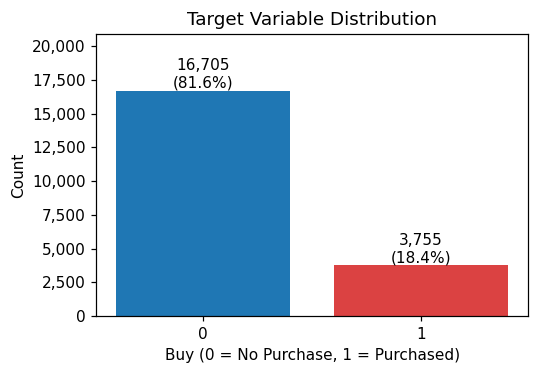

In [7]:
fig, ax = plt.subplots(figsize=(5, 3.5))

bars = ax.bar(counts.index.astype(str), counts.values, color=['#1f77b4', '#db4242'])

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:,}\n({height/len(df_raw):.1%})',
            ha='center', va='bottom')

ax.set_title('Target Variable Distribution')
ax.set_xlabel('Buy (0 = No Purchase, 1 = Purchased)')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set_ylim(0, counts.values.max() * 1.25)
plt.tight_layout()
plt.show()

### 2.2 Purchase Rate by Key Categorical Features

This analysis examines how purchase rates vary across key categorical features by calculating the average value of the target variable (buy) within each group.
Several strong signals emerge:

- **`has_v_insurance`**: customers *without* existing car insurance are far more likely to purchase — intuitively, they have higher need.
- **`v_accident`**: customers with prior vehicle accidents show elevated purchase rates.
- **`v_age`**: older vehicles correlate with higher purchase intent.
- **`gender`** and **`dl`**: moderate effects.

These patterns directly inform the interaction features we engineer in Section 3.


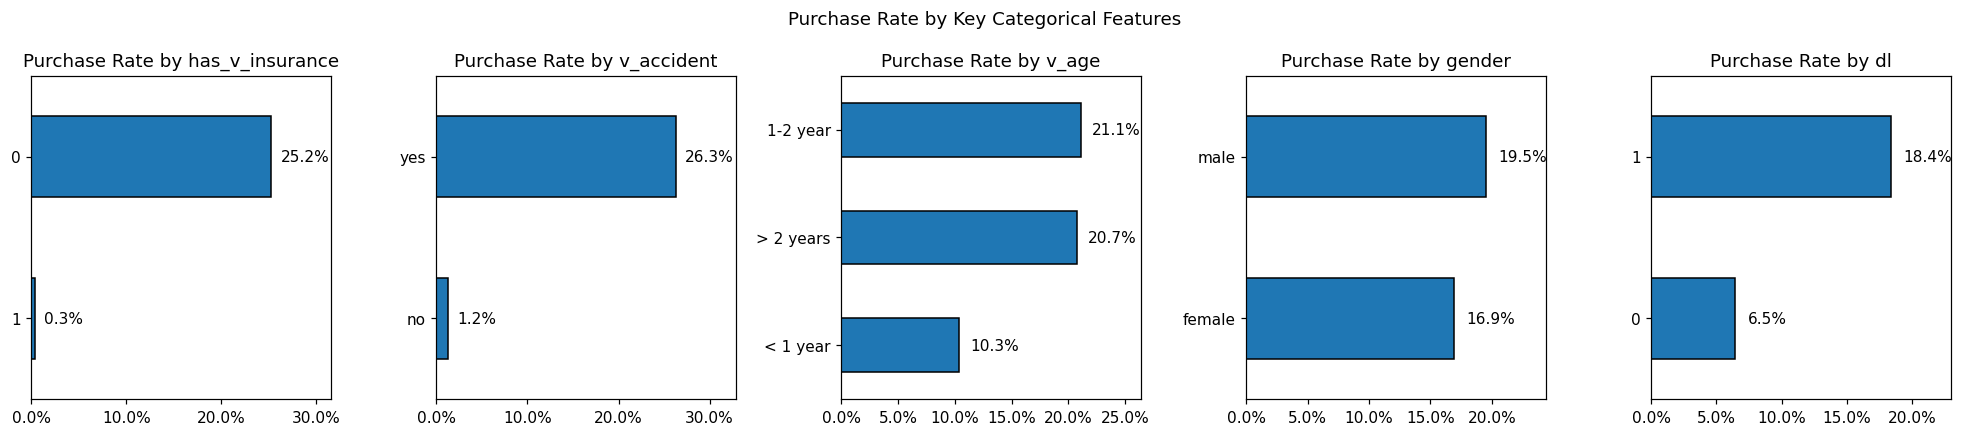

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, ['has_v_insurance', 'v_accident', 'v_age', 'gender', 'dl']):
    rates = df_raw.groupby(col)['buy'].mean().sort_values()
    rates.plot(kind='barh', ax=ax, color='#1f77b4', edgecolor='black')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title('Purchase Rate by ' + col)
    ax.set_xlim(0, max(rates) * 1.25)
    ax.set_ylabel('')
    for bar, val in zip(ax.patches, rates):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.1%}', va='center')

plt.suptitle('Purchase Rate by Key Categorical Features')
plt.tight_layout()
plt.show()

### 2.3 Regional Variation in Purchase Rate

`region` is a high-cardinality numeric code with many distinct values.
The wide spread in purchase rate across regions (shown below) justifies **target encoding**
rather than one-hot encoding — target encoding captures the predictive signal without
creating hundreds of sparse dummy columns, increasing noise and hurting generalization


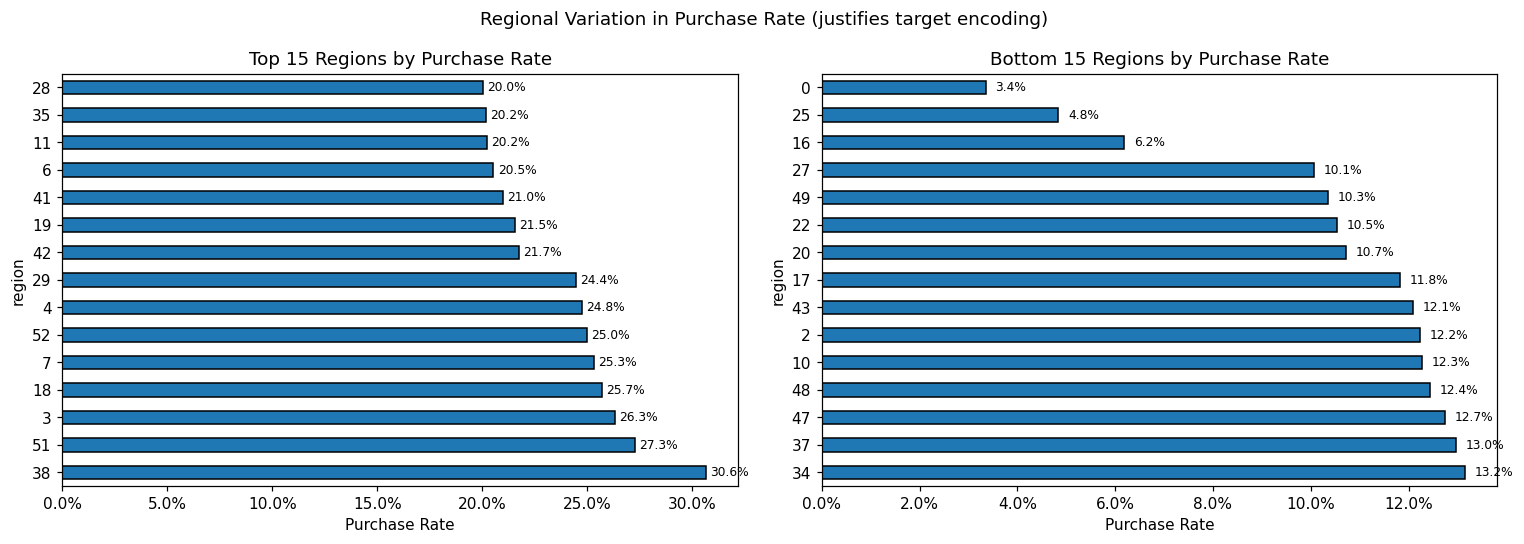

Region purchase rate range: 3.4% — 30.6%


In [9]:
# Top and bottom 15 regions by purchase rate
region_rates = df_raw.groupby('region')['buy'].mean().sort_values(ascending=False)
top15    = region_rates.head(15)
bottom15 = region_rates.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title in zip(axes,
                           [top15, bottom15],
                           ['Top 15 Regions by Purchase Rate', 'Bottom 15 Regions by Purchase Rate']):
    data.plot(kind='barh', ax=ax, color='#1f77b4', edgecolor='black')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(title)
    ax.set_xlabel('Purchase Rate')
    for bar, val in zip(ax.patches, data):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.1%}', va='center', fontsize=8)

plt.suptitle('Regional Variation in Purchase Rate (justifies target encoding)')
plt.tight_layout()
plt.show()
print(f'Region purchase rate range: {region_rates.min():.1%} — {region_rates.max():.1%}')

### 2.4 Numerical Feature Distributions by Purchase Outcome

Overlapping histograms reveal how `age`, `tenure`, and `v_prem_quote` differ between purchasers and non-purchasers.
Box plots additionally highlight the presence of outliers in `v_prem_quote` — premium quotes vary widely,
which motivates a log-transform in feature engineering.




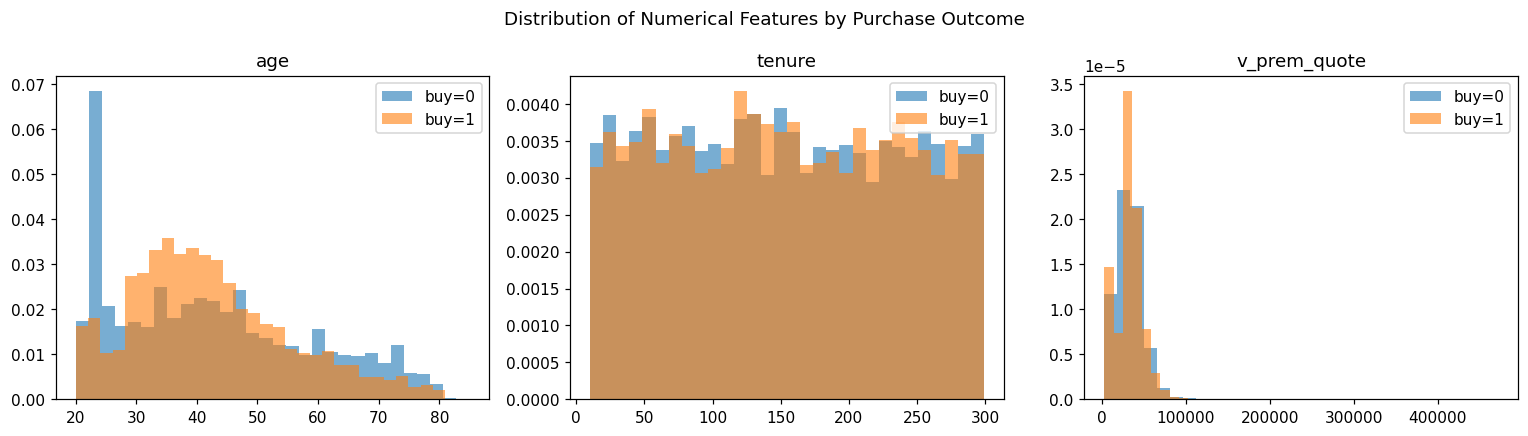

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['age', 'tenure', 'v_prem_quote']):
    for label, grp in df_raw.groupby('buy'):
        ax.hist(grp[col], bins=30, alpha=0.6, label=f'buy={label}', density=True)
    ax.set_title(col)
    ax.legend()

plt.suptitle('Distribution of Numerical Features by Purchase Outcome')
plt.tight_layout()
plt.show()

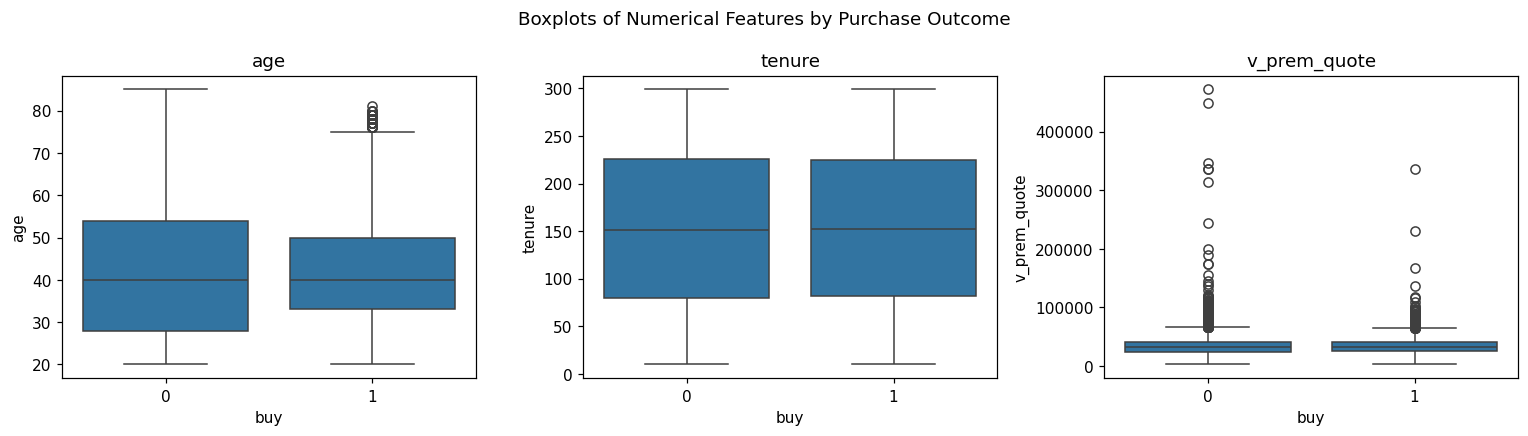

In [11]:
# Outlier diagnosis via stratified boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['age', 'tenure', 'v_prem_quote']):
    sns.boxplot(x='buy', y=col, data=df_raw, ax=ax)
    ax.set_title(col)

plt.suptitle('Boxplots of Numerical Features by Purchase Outcome')
plt.tight_layout()
plt.show()

### 2.5 Correlation Analysis
This correlation analysis examines the linear relationships between key numerical features and the target variable. The heatmap shows that has_v_insurance has the strongest negative correlation with the target variable buy, indicating that customers who already have vehicle insurance are less likely to purchase additional insurance. Other features such as age and v_prem_quote show weak but noticeable positive relationships, suggesting they have some influence on purchasing behavior, although not strongly on their own. Variables like tenure and dl display near-zero correlations, meaning they do not have strong linear relationships individually with the target. Overall, this analysis highlights that while some features provide useful signals, many relationships are relatively weak, suggesting that more complex models or feature interactions are needed to capture deeper patterns in the data.

Notable observations:
- `has_v_insurance` shows the strongest negative correlation with `buy` (confirmed the EDA above).
- `age` and `v_prem_quote` have modest but real relationships with the target.
- `dl` and `tenure` show weaker standalone correlations but remain useful in interaction features.


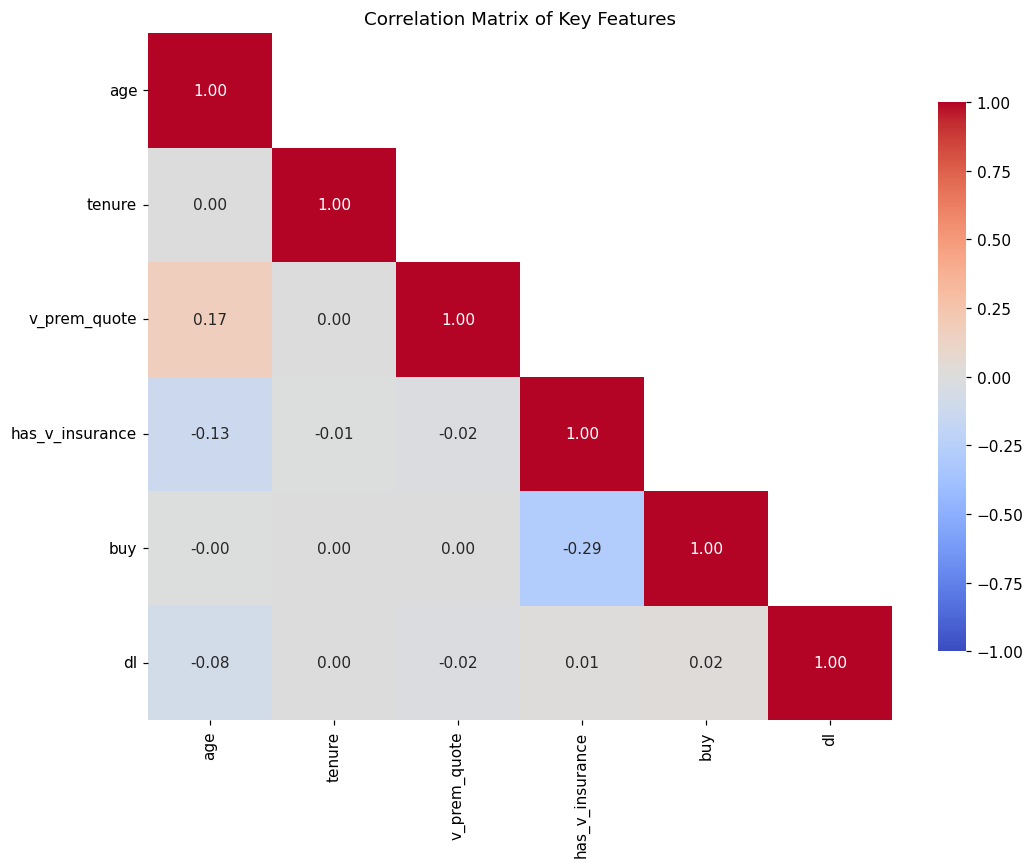

In [12]:
cor_eda = ['age', 'tenure', 'v_prem_quote', 'has_v_insurance', 'buy', 'dl']
corr = df_raw[cor_eda].corr()

fig = plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, mask=mask, cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix of Key Features')
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering & Preprocessing

### 3.1 Feature Engineering Function

Raw features are transformed and new interaction variables are constructed to give models richer
signals. The `engineer_features` function is applied identically to training and score data to avoid
train/score mismatch.

**New features and rationale:**

| Feature | Construction | Rationale |
|---|---|---|
| `tenure_yr` | `tenure / 365` | Expresses tenure in interpretable years |
| `log_prem` | `log1p(v_prem_quote)` | Reduces right-skew in premium quotes |
| `prem_per_age` | `v_prem_quote / (age + 1)` | Relative affordability signal |
| `no_ins_x_acc` | `(no insurance) AND (had accident)` | High-need customers: no coverage yet had accident |
| `dl_x_no_ins` | `dl × (1 - has_v_insurance)` | Licensed driver without insurance — prime cross-sell target |
| `v_age_ord` | Ordinal map of `v_age` | Converts categorical to ordered numeric |
| `gender_bin` | Binary of `gender` | Required for numeric models |
| `acc_bin` | Binary of `v_accident` | Required for numeric models |
| `age_x_prem` | `age × log_prem` | Interaction: older customers paying more |
| `age_sq_norm` | `age² / 1000` | Non-linear age effect |
| `tenure_sq` | `tenure² / 1e6` | Non-linear tenure effect |
| `age_bucket` | 6 age bands | Captures non-monotonic age relationships |
| `risk_score` | Sum of 3 risk flags | Composite risk indicator |
| `buy_readiness` | Licensed + no insurance + older vehicle | Multi-condition purchase propensity |
| `prem_per_tenure` | `v_prem_quote / (tenure + 1)` | Annual cost relative to relationship length |


In [13]:
def engineer_features(df):
    """Apply all feature transformations identically to any split of the data."""
    df = df.copy()

    # Temporal / scale transforms
    df['tenure_yr']    = df['tenure'] / 365
    df['log_prem']     = np.log1p(df['v_prem_quote'])
    df['prem_per_age'] = df['v_prem_quote'] / (df['age'] + 1)

    # Binary interaction features (no-insurance × accident)
    df['no_ins_x_acc'] = ((df['has_v_insurance'] == 0) & (df['v_accident'] == 'yes')).astype(int)
    df['dl_x_no_ins']  = df['dl'] * (1 - df['has_v_insurance'])

    # Ordinal and binary encodings of categorical columns
    df['v_age_ord']  = df['v_age'].map({'< 1 year': 0, '1-2 year': 1, '> 2 years': 2})
    df['gender_bin'] = (df['gender'] == 'male').astype(int)
    df['acc_bin']    = (df['v_accident'] == 'yes').astype(int)

    # Polynomial / non-linear terms
    df['age_x_prem']  = df['age'] * np.log1p(df['v_prem_quote'])
    df['age_sq_norm'] = (df['age'] ** 2) / 1000
    df['tenure_sq']   = (df['tenure'] ** 2) / 1e6

    # Bucketing and composite risk scores
    df['age_bucket']  = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 100], labels=False)
    df['risk_score']  = ((1 - df['has_v_insurance'])
                         + df['acc_bin']
                         + (df['v_age_ord'] >= 1).astype(int))
    df['buy_readiness'] = (df['dl']
                           * (1 - df['has_v_insurance'])
                           * (df['v_age_ord'] >= 1).astype(int))
    df['prem_per_tenure'] = df['v_prem_quote'] / (df['tenure'] + 1)

    return df

# Apply to both datasets
df_train = engineer_features(df_raw)
df_score = engineer_features(df_score)

print('Feature engineering complete.')
print(f'Columns added: {len(df_train.columns) - len(df_raw.columns)}')
df_train.info()

Feature engineering complete.
Columns added: 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20460 entries, 0 to 20459
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_new           20460 non-null  object 
 1   buy              20460 non-null  int64  
 2   age              20460 non-null  int64  
 3   gender           20460 non-null  object 
 4   tenure           20460 non-null  int64  
 5   region           20460 non-null  int64  
 6   dl               20460 non-null  int64  
 7   has_v_insurance  20460 non-null  int64  
 8   v_age            20460 non-null  object 
 9   v_accident       20460 non-null  object 
 10  v_prem_quote     20460 non-null  float64
 11  cs_rep           20460 non-null  int64  
 12  tenure_yr        20460 non-null  float64
 13  log_prem         20460 non-null  float64
 14  prem_per_age     20460 non-null  float64
 15  no_ins_x_acc     20460 non-null  int64  
 16  dl_x_no_in

**Correlation check on engineered features:**  
We verify that our new features add signal without introducing problematic collinearity that would
destabilise linear models. Tree-based models are robust to high correlation, but this check informs
feature selection.


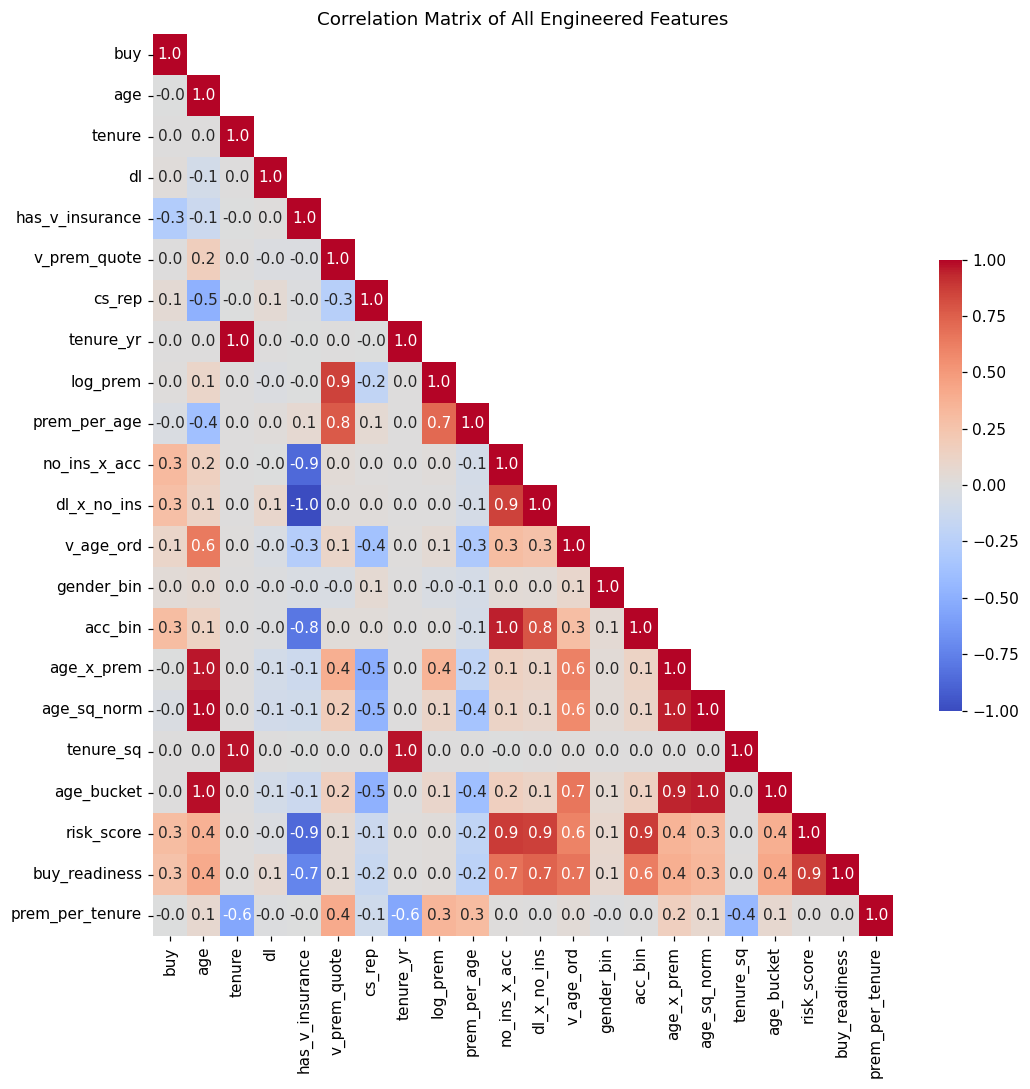

In [14]:
# Correlation heatmap on all numeric engineered features
df_corr = df_train.drop(columns=['gender', 'region', 'v_age', 'id_new', 'v_accident'])
corr = df_corr.corr()

fig = plt.figure(figsize=(10, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.1f', cmap='coolwarm',
            vmin=-1, vmax=1, mask=mask, cbar_kws={'shrink': 0.5})

plt.title('Correlation Matrix of All Engineered Features')
plt.tight_layout()
plt.show()

### 3.2 Target Encoding for High-Cardinality Columns

Both `region` and `cs_rep` are numeric codes with many distinct values (unsuitable for one-hot encoding).
We apply **cross-validated target encoding** to prevent leakage:

- For each of the 10 CV folds, the target mean is computed on the training portion of that fold and
  applied to the validation portion.
- This ensures no row's own label influences its encoded value, preventing target-leakage-induced optimism.
- For the score dataset, we apply target means computed on the *full* training set (standard practice).

**Why not one-hot encode?** With hundreds of region/rep codes, OHE would create a very wide and sparse
feature matrix, hurting both computational efficiency and model generalization.


In [15]:
y = df_raw['buy'].values

# 10-fold stratified split — reused throughout for consistent CV
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
global_mean = y.mean()

# Cross-validated target encoding on training set (avoids leakage)
for col in ['cs_rep', 'region']:
    df_train[f'{col}_enc'] = 0.0
    for tr_idx, va_idx in cv10.split(df_train, y):
        fold_means = df_raw.iloc[tr_idx].groupby(col)['buy'].mean()
        df_train.loc[df_train.index[va_idx], f'{col}_enc'] = \
            df_train.iloc[va_idx][col].map(fold_means).fillna(global_mean)

# Apply full-data target means to score set
te_maps = {}
for col in ['cs_rep', 'region']:
    te_maps[col] = df_raw.groupby(col)['buy'].mean()
    df_score[f'{col}_enc'] = df_score[col].map(te_maps[col]).fillna(global_mean)

print('Target encoding complete.')
display(df_train[['region', 'region_enc', 'cs_rep', 'cs_rep_enc']].head(10))

Target encoding complete.


,region,region_enc,cs_rep,cs_rep_enc
0,19,0.241379,154,0.243882
1,34,0.147059,154,0.244734
2,29,0.252551,163,0.304516
3,3,0.282209,154,0.246256
4,28,0.198686,122,0.173211
5,45,0.139623,151,0.031506
6,28,0.198900,122,0.172384
7,28,0.198900,122,0.172384
8,28,0.198782,122,0.172679
9,28,0.201004,122,0.174331


### 3.3 Final Feature Selection & Train/Test Split

After feature engineering, we selected a final set of **13 predictors** using a combined data-driven and domain-informed selection strategy. The selection process was based on three criteria:

- Predictive signal strength (EDA):
Features were first evaluated through exploratory data analysis, including group-wise purchase rates, distribution shifts between classes, and correlation with the target variable. Variables exhibiting clear class separation or consistent monotonic trends (e.g., has_v_insurance, v_accident, v_age) were prioritized.
- Incremental contribution in multivariate context:
Beyond univariate signal, we retained features that demonstrated additional predictive value when interacting with other variables, as evidenced by tree-based model importance and interaction effects captured during preliminary model fitting. This helped ensure that selected features contributed complementary rather than redundant information.
- Multicollinearity and redundancy control:
Highly correlated variables were carefully reviewed to avoid redundancy. When strong correlation existed, preference was given to the feature with stronger interpretability or higher model importance, ensuring a compact and non-redundant feature space. we tend to removed the engineered features first when they are highly correlated with the original ones

This process resulted in a parsimonious feature set that balances predictive power, interpretability, and robustness across different model families.

To evaluate generalization performance, we created a stratified 80/20 train–test split, ensuring that both subsets preserve the original class distribution. This is particularly important in an imbalanced classification setting, as it guarantees that performance metrics on the hold-out set remain representative of real-world class proportions.


In [16]:
FEAT_COLS = [
    'age', 'dl', 'has_v_insurance',
    'prem_per_tenure', 'tenure_yr', 'log_prem', 'prem_per_age',
    'v_age_ord', 'gender_bin','buy_readiness',  'risk_score', 
    'cs_rep_enc', 'region_enc'
]  

print('Final feature set:', FEAT_COLS)
print('Total features   :', len(FEAT_COLS))

X_valu        = df_train[FEAT_COLS].values
X_score_valu  = df_score[FEAT_COLS].values

# Stratified 80/20 split preserves class balance in both partitions
X_tr, X_tes, y_train, y_test = train_test_split(
    X_valu, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain size : {X_tr.shape[0]:,}  | Positive rate: {y_train.mean():.1%}')
print(f'Test size  : {X_tes.shape[0]:,}  | Positive rate: {y_test.mean():.1%}')

Final feature set: ['age', 'dl', 'has_v_insurance', 'prem_per_tenure', 'tenure_yr', 'log_prem', 'prem_per_age', 'v_age_ord', 'gender_bin', 'buy_readiness', 'risk_score', 'cs_rep_enc', 'region_enc']
Total features   : 13

Train size : 16,368  | Positive rate: 18.4%
Test size  : 4,092  | Positive rate: 18.4%


### 3.4 Feature Scaling

`StandardScaler` is fitted **only on the training fold** and applied to all other splits.
This prevents data leakage from test/score statistics into the model.

- `X_train_scaled` / `X_test_scaled` — used during model selection and hold-out evaluation.
- `X_full_scaled` / `X_score_scaled` — used when refitting the final model on all available labels
  and scoring the submission set.


In [17]:
# Scaler fitted on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_tr)
X_test_scaled  = scaler.transform(X_tes)

# Scaler fitted on full labelled data for final refit
X_full_scaled  = scaler.fit_transform(X_valu)
X_score_scaled = scaler.transform(X_score_valu)

print('Scaling complete.')
print(f'Train scaled shape : {X_train_scaled.shape}')
print(f'Score scaled shape : {X_score_scaled.shape}')

Scaling complete.
Train scaled shape : (16368, 13)
Score scaled shape : (2000, 13)


---
## 4. Model Development & Evaluation

This section included:

- Use of Out-of-Fold (OOF) predictions as the true performance estimate

- Algorithm diversity to capture different data patterns

- Threshold optimization for imbalanced classification

- Weight-optimized ensembling to exceed single-model limits

All models are evaluated using **10-fold stratified cross-validation** on `X_train_scaled`.
For each model we report:

- **CV AUC** (mean ± std across folds) — the primary ranking metric.
- **OOF AUC** — Area Under the ROC Curve computed on Out-of-Fold predictions 

We decided to use 10-fold cross-validation because it provides a good balance between computational efficiency and reliable performance estimation. By splitting the data into 10 subsets, the model is trained and tested multiple times on different portions of the data, which reduces the impact of randomness from any single split.

Using fewer folds (like 3 or 5) may lead to higher bias and less reliable results, while using more folds (like 20 or leave-one-out cross-validation) increases computational cost without significantly improving performance estimates. Therefore, 10 folds is widely accepted as a standard because it offers stable and consistent results without being too computationally expensive.


Grid search is deliberately constrained to a manageable hyperparameter space to balance
exploration time against marginal gains.

**Why So Many Models?**

Different algorithms capture different patterns:
| Model Type          | Strength                                |
|---------------------|------------------------------------------|
| Logistic Regression | Strong linear baseline, interpretable    |
| Tree Ensembles      | Capture non-linear interactions          |
| Gradient Boosting   | State-of-the-art tabular performance     |
| KNN                 | Distance-based local patterns            |
| PCA + MLP           | Tests dimensionality reduction benefit   |

This wide comparison ensures no good approach is overlooked. Moreover this also allows us to build better ensemble models

<span style="color:red"> **NOTE: During testing, we explored a significantly larger hyperparameter space. For this final submission, we reduced the search space to improve efficiency and save computational time. the comments next to the grids are those we tested** </span>
### 4.1 Baseline Models with 10-Fold CV Grid Search

#### Logistic Regression (with SMOTE)

Logistic Regression establishes a strong linear baseline. We wrap it in an `ImbPipeline` with
SMOTE to oversample the minority class inside each fold — preventing synthetic samples from the
validation fold contaminating training, which would inflate metrics. We also included scaler in the pipeline to prevenet leaking test-fold statistics


In [18]:
# Logistic Regression with SMOTE oversampling inside each CV fold
lo_pipe = ImbPipeline([
    ('scaler', StandardScaler()),   
    ('smote', SMOTE(random_state=42)),
    ('logreg', LogisticRegression(random_state=42))
])

param_grid_logreg = {
    'logreg__C':       [0.01, 0.1, 1, 10],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver':  ['liblinear']
}

grid_search_logreg = GridSearchCV(lo_pipe,param_grid_logreg,
                                  cv=cv10, scoring='roc_auc', n_jobs=-1)

grid_search_logreg.fit(X_tr, y_train)   

print('Best CV AUC :', round(grid_search_logreg.best_score_, 4))
print('Best Params :', grid_search_logreg.best_params_)

oof_logreg = cross_val_predict( grid_search_logreg.best_estimator_, 
                               X_tr, y_train,
                               cv=cv10, method='predict_proba')[:, 1]

print('Logistic Regression OOF AUC:', round(roc_auc_score(y_train, oof_logreg), 4))

Best CV AUC : 0.7637
Best Params : {'logreg__C': 1, 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}
Logistic Regression OOF AUC: 0.7635


#### Random Forest

Random Forests are an ensemble of uncorrelated decision trees that generalize well.
We tune `n_estimators`, `max_depth`, `min_samples_leaf`, and `class_weight`.


In [19]:
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators':    [400],  # [200,300,400]
    'max_depth':       [9],     #[9,10,12, 7]
    'min_samples_leaf':[30],    # [20,30,40]
    'class_weight':    ['balanced', None]
}

grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=cv10, scoring='roc_auc', n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)

print('Best CV AUC :', round(grid_search_rf.best_score_, 4))
print('Best Params :', grid_search_rf.best_params_)

oof_rf = cross_val_predict(grid_search_rf.best_estimator_,
                            X_train_scaled, y_train, cv=cv10, method='predict_proba')[:, 1]
print('Random Forest OOF AUC:', round(roc_auc_score(y_train, oof_rf), 4))

Best CV AUC : 0.7729
Best Params : {'class_weight': None, 'max_depth': 9, 'min_samples_leaf': 30, 'n_estimators': 400}
Random Forest OOF AUC: 0.7722


#### Gradient Boosting Classifier

Sklearn's sequential boosting algorithm. We tune `n_estimators`, `learning_rate`, `max_depth`,
`min_samples_leaf`, and `subsample` (stochastic gradient boosting).


In [20]:
gbc = GradientBoostingClassifier(random_state=42)
param_grid_gbc = {
    'n_estimators':    [200, 300], # [100,200,300]
    'learning_rate':   [0.02, 0.05], # [0.01, 0.02, 0.05]
    'max_depth':       [4, 5],  # [3,4,5]
    'min_samples_leaf':[30],  # [20,30,40]
    'subsample':       [0.8] # [0.6, 0.8, 1.0]
}

grid_search_gbc = GridSearchCV(gbc, param_grid_gbc, cv=cv10, scoring='roc_auc', n_jobs=-1)
grid_search_gbc.fit(X_train_scaled, y_train)

print('Best CV AUC :', round(grid_search_gbc.best_score_, 4))
print('Best Params :', grid_search_gbc.best_params_)

oof_gbc = cross_val_predict(grid_search_gbc.best_estimator_,
                             X_train_scaled, y_train, cv=cv10, method='predict_proba')[:, 1]
print('Gradient Boosting OOF AUC:', round(roc_auc_score(y_train, oof_gbc), 4))

Best CV AUC : 0.7759
Best Params : {'learning_rate': 0.02, 'max_depth': 4, 'min_samples_leaf': 30, 'n_estimators': 200, 'subsample': 0.8}
Gradient Boosting OOF AUC: 0.775


#### HistGradientBoosting Classifier

An optimized histogram-based gradient boosting implementation, similar in spirit to LightGBM.
Often faster and comparable in accuracy to GBC on larger datasets.


In [21]:
hgbc = HistGradientBoostingClassifier(random_state=42)
param_grid_hgbc = {
    'max_iter':        [100, 200, 300],
    'learning_rate':   [0.01, 0.02, 0.05, 0.1],
    'max_depth':       [3, 5, 7],
    'min_samples_leaf':[10, 20, 30],
}

grid_search_hgbc = GridSearchCV(hgbc, param_grid_hgbc, cv=cv10, scoring='roc_auc', n_jobs=-1)
grid_search_hgbc.fit(X_train_scaled, y_train)

print('Best CV AUC :', round(grid_search_hgbc.best_score_, 4))
print('Best Params :', grid_search_hgbc.best_params_)

oof_hgbc = cross_val_predict(grid_search_hgbc.best_estimator_,
                              X_train_scaled, y_train, cv=cv10, method='predict_proba')[:, 1]
print('HistGradientBoosting OOF AUC:', round(roc_auc_score(y_train, oof_hgbc), 4))

Best CV AUC : 0.7745
Best Params : {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 300, 'min_samples_leaf': 30}
HistGradientBoosting OOF AUC: 0.7741


#### MLP Classifier (Scikit-Learn)

A feedforward neural network with configurable hidden layers. We tune architecture
(`hidden_layer_sizes`), activation function, regularization (`alpha`), and learning rate.
Scaling is critical for MLP convergence — already handled by `X_train_scaled`.


In [22]:
mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),   
    ('mlp', MLPClassifier(random_state=42))
])
param_grid_mlp = {
    'mlp__hidden_layer_sizes':  [(50,)], # [(50,), (100,), (50,50), (100,50), (128,64,32 )]
    'mlp__activation':          ['relu'], # ['relu', 'tanh']
    'mlp__alpha':               [0.0001, 0.001], # [0.0001, 0.001, 0.01]
    'mlp__learning_rate_init':  [0.001, 0.0005], # [0.001, 0.0005, 0.0001]
    'mlp__max_iter':            [200, 500] # [200,300, 500]
}

grid_search_mlp = GridSearchCV(mlp_pipe, param_grid_mlp, cv=cv10, scoring='roc_auc', n_jobs=-1)
grid_search_mlp.fit(X_tr, y_train)

print('Best CV AUC :', round(grid_search_mlp.best_score_, 4))
print('Best Params :', grid_search_mlp.best_params_)

oof_mlp = cross_val_predict(grid_search_mlp.best_estimator_,
                             X_tr, y_train, cv=cv10, method='predict_proba')[:, 1]
print('MLP OOF AUC:', round(roc_auc_score(y_train, oof_mlp), 4))

Best CV AUC : 0.7694
Best Params : {'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50,), 'mlp__learning_rate_init': 0.0005, 'mlp__max_iter': 200}
MLP OOF AUC: 0.7688


#### Extra Trees Classifier

Similar to Random Forest but trees are built with fully random splits rather than best-found splits.
This increases diversity among trees (useful for ensembling) at some cost to individual accuracy.


In [23]:
xtree = ExtraTreesClassifier(random_state=42)
param_grid_xtree = {
    'n_estimators':    [100, 200, 400], # [100,200,300, 400]
    'max_depth':       [9, 12, 15],   
    'min_samples_leaf':[10, 20, 30]
}

grid_search_xtree = GridSearchCV(xtree, param_grid_xtree, cv=cv10, scoring='roc_auc', n_jobs=-1)
grid_search_xtree.fit(X_train_scaled, y_train)

print('Best CV AUC :', round(grid_search_xtree.best_score_, 4))
print('Best Params :', grid_search_xtree.best_params_)

oof_xtree = cross_val_predict(grid_search_xtree.best_estimator_,
                               X_train_scaled, y_train, cv=cv10, method='predict_proba')[:, 1]
print('Extra Trees OOF AUC:', round(roc_auc_score(y_train, oof_xtree), 4))

Best CV AUC : 0.7738
Best Params : {'max_depth': 15, 'min_samples_leaf': 10, 'n_estimators': 400}
Extra Trees OOF AUC: 0.7733


#### K-Nearest Neighbors

KNN classifies each instance based on the majority class among its `k` nearest neighbors.
We tune `n_neighbors`, `weights`, and `metric`. Very high `k` values are explored since
the dataset is large and minority class is sparse.


In [24]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),   
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': [100, 200, 500],
    'knn__weights':     ['uniform', 'distance'],
    'knn__metric':      ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(knn_pipe, param_grid_knn, cv=cv10, scoring='roc_auc', n_jobs=-1)
grid_search_knn.fit(X_tr, y_train)

print('Best CV AUC :', round(grid_search_knn.best_score_, 4))
print('Best Params :', grid_search_knn.best_params_)

oof_knn = cross_val_predict(grid_search_knn.best_estimator_,
                             X_tr, y_train, cv=cv10, method='predict_proba')[:, 1]
print('KNN OOF AUC:', round(roc_auc_score(y_train, oof_knn), 4))

Best CV AUC : 0.7608
Best Params : {'knn__metric': 'manhattan', 'knn__n_neighbors': 500, 'knn__weights': 'distance'}
KNN OOF AUC: 0.7603


#### XGBoost

XGBoost is a highly optimized gradient boosting library, widely successful in tabular ML competitions.
We use `scale_pos_weight` (computed as the negative-to-positive class ratio) to handle imbalance
directly within the algorithm.


In [25]:
# Class imbalance ratio for scale_pos_weight
scale_pos = (y == 0).sum() / (y == 1).sum()
print(f'scale_pos_weight = {scale_pos:.2f}  (neg/pos ratio)')

xgb_clf = XGBClassifier(random_state=42, eval_metric='auc',
                         use_label_encoder=False, n_jobs=-1)
param_grid_xgb = {
    'n_estimators':     [200, 400],
    'learning_rate':    [0.03, 0.05, 0.1],
    'max_depth':        [4, 6],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, scale_pos]
}

grid_xgb = GridSearchCV(xgb_clf, param_grid_xgb, cv=cv10, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)

print('XGBoost Best CV AUC  :', round(grid_xgb.best_score_, 4))
print('XGBoost Best Params  :', grid_xgb.best_params_)

oof_xgb = cross_val_predict(grid_xgb.best_estimator_,
                             X_train_scaled, y_train, cv=cv10, method='predict_proba')[:, 1]
print(f'XGBoost OOF AUC: {roc_auc_score(y_train, oof_xgb):.4f}')

scale_pos_weight = 4.45  (neg/pos ratio)
XGBoost Best CV AUC  : 0.7756
XGBoost Best Params  : {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 1.0}
XGBoost OOF AUC: 0.7748


#### LightGBM

LightGBM (LGBM) uses a leaf-wise tree growth strategy and histogram-based binning, making it
typically faster and often more accurate than traditional gradient boosting on large tabular datasets.
We tune `n_estimators`, `learning_rate`, `max_depth`, `num_leaves`, and `class_weight`.


In [26]:
lgbm_clf = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
param_grid_lgbm = {
    'n_estimators':  [200, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth':     [4, 6, 8],
    'num_leaves':    [31, 63],
    'class_weight':  ['balanced', None]
}

grid_lgbm = GridSearchCV(lgbm_clf, param_grid_lgbm, cv=cv10, scoring='roc_auc', n_jobs=-1)
grid_lgbm.fit(X_train_scaled, y_train)

print('LightGBM Best CV AUC :', round(grid_lgbm.best_score_, 4))
print('LightGBM Best Params :', grid_lgbm.best_params_)

oof_lgbm = cross_val_predict(grid_lgbm.best_estimator_,
                              X_train_scaled, y_train, cv=cv10, method='predict_proba')[:, 1]
print(f'LightGBM OOF AUC: {roc_auc_score(y_train, oof_lgbm):.4f}')

LightGBM Best CV AUC : 0.7757
LightGBM Best Params : {'class_weight': 'balanced', 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'num_leaves': 31}
LightGBM OOF AUC: 0.7750


#### PCA + MLP

Principal Component Analysis reduces the 13 features to a lower-dimensional subspace before
feeding them into an MLP. The rationale is that decorrelated principal components may improve
MLP gradient descent convergence. Results here help determine whether dimensionality reduction
adds value.


In [27]:

pipe_pca_mlp = Pipeline([
    ('scaler', StandardScaler()),   
    ('pca', PCA()),
    ('mlp', MLPClassifier(random_state=42))
])

param_grid_pca = {
    'pca__n_components':       [10],
    'pca__whiten':             [False],
    'mlp__hidden_layer_sizes': [(50,), (100,)], # [(50,), (100,), (50,50), (100,50), (128,64,32 )]
    'mlp__activation':         ['relu'],    # ['relu', 'tanh']
    'mlp__alpha':              [0.0001, 0.001], # [0.0001, 0.001, 0.01]
    'mlp__learning_rate_init': [0.001, 0.0005], # [0.001, 0.0005, 0.0001]
    'mlp__max_iter':           [200]  # [200,300, 500]
}


grid_search_pca = GridSearchCV(pipe_pca_mlp, param_grid_pca, cv=cv10, scoring='roc_auc', n_jobs=-1)
grid_search_pca.fit(X_tr, y_train)

print('Best CV AUC :', round(grid_search_pca.best_score_, 4))
print('Best Params :', grid_search_pca.best_params_)

oof_pca = cross_val_predict(grid_search_pca.best_estimator_,
                             X_tr, y_train, cv=cv10, method='predict_proba')[:, 1]
print(f'PCA + MLP OOF AUC: {roc_auc_score(y_train, oof_pca):.4f}')

Best CV AUC : 0.7679
Best Params : {'mlp__activation': 'relu', 'mlp__alpha': 0.001, 'mlp__hidden_layer_sizes': (50,), 'mlp__learning_rate_init': 0.0005, 'mlp__max_iter': 200, 'pca__n_components': 10, 'pca__whiten': False}
PCA + MLP OOF AUC: 0.7675


#### CatBoost

CatBoost is a gradient boosting algorithm with built-in handling of categorical features and
ordered boosting to avoid target leakage. We apply `scale_pos_weight` for class imbalance.


In [28]:
cb = CatBoostClassifier(random_state=42, verbose=0)
param_grid_cb = {
    'iterations':       [200], # [100, 200, 300]
    'learning_rate':    [0.03], # [0.01, 0.03, 0.05]
    'depth':            [6], # [4, 6, 8]
    'l2_leaf_reg':      [1, 3, 5], # [1, 3, 5]
    'scale_pos_weight': [1, float(scale_pos)]
}

grid_search_cb = GridSearchCV(cb, param_grid_cb, cv=cv10, scoring='roc_auc', n_jobs=-1)
grid_search_cb.fit(X_tr, y_train)

print('Best CV AUC :', round(grid_search_cb.best_score_, 4))
print('Best Params :', grid_search_cb.best_params_)

best_params_cb = dict(grid_search_cb.best_params_)
best_params_cb['scale_pos_weight'] = float(best_params_cb['scale_pos_weight'])

cb_best = CatBoostClassifier(**best_params_cb, random_state=42, verbose=0)
oof_cb  = cross_val_predict(cb_best, X_tr, y_train,
                             cv=cv10, method='predict_proba', n_jobs=-1)[:, 1]
print(f'CatBoost OOF AUC: {roc_auc_score(y_train, oof_cb):.4f}')

Best CV AUC : 0.7742
Best Params : {'depth': 6, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.03, 'scale_pos_weight': 4.448735019973369}
CatBoost OOF AUC: 0.7735


### 4.2 Model Comparison

We aggregate OOF AUC scores for all tuned models to identify the top performers and
candidates for ensembling.

we used OOF predictions because simulate how the model behaves on unseen data.
They are also required for valid ensembling, because we can blend model predictions without leaking information.


In [29]:
benchmark_models = {
    'Logistic Regression':  grid_search_logreg.best_estimator_,
    'Random Forest':        grid_search_rf.best_estimator_,
    'Gradient Boosting':    grid_search_gbc.best_estimator_,
    'HistGradientBoosting': grid_search_hgbc.best_estimator_,
    'MLP':                  grid_search_mlp.best_estimator_,
    'Extra Trees':          grid_search_xtree.best_estimator_,
    'KNN':                  grid_search_knn.best_estimator_,
    'PCA + MLP':            grid_search_pca.best_estimator_,
    'XGBoost':              grid_xgb.best_estimator_,
    'LightGBM':             grid_lgbm.best_estimator_,
    'CatBoost':             grid_search_cb.best_estimator_
}

results = {}
for name, clf in benchmark_models.items():
    aucs    = cross_val_score(clf, X_train_scaled, y_train, cv=cv10, scoring='roc_auc')
    oof_p   = cross_val_predict(clf, X_train_scaled, y_train,
                                cv=cv10, method='predict_proba', n_jobs=-1)[:, 1]
    results[name] = {'mean': aucs.mean(), 'std': aucs.std(), 'oof_prob': oof_p}
    print(f'  {name:28s}  CV AUC: {aucs.mean():.4f} ± {aucs.std():.4f}'
          f'  |  OOF AUC: {roc_auc_score(y_train, oof_p):.4f}')

  Logistic Regression           CV AUC: 0.7637 ± 0.0091  |  OOF AUC: 0.7635
  Random Forest                 CV AUC: 0.7729 ± 0.0096  |  OOF AUC: 0.7722
  Gradient Boosting             CV AUC: 0.7759 ± 0.0089  |  OOF AUC: 0.7750
  HistGradientBoosting          CV AUC: 0.7745 ± 0.0101  |  OOF AUC: 0.7741
  MLP                           CV AUC: 0.7694 ± 0.0112  |  OOF AUC: 0.7688
  Extra Trees                   CV AUC: 0.7738 ± 0.0095  |  OOF AUC: 0.7733
  KNN                           CV AUC: 0.7608 ± 0.0096  |  OOF AUC: 0.7603
  PCA + MLP                     CV AUC: 0.7679 ± 0.0130  |  OOF AUC: 0.7675
  XGBoost                       CV AUC: 0.7756 ± 0.0080  |  OOF AUC: 0.7748
  LightGBM                      CV AUC: 0.7757 ± 0.0090  |  OOF AUC: 0.7750
  CatBoost                      CV AUC: 0.7742 ± 0.0094  |  OOF AUC: 0.7735


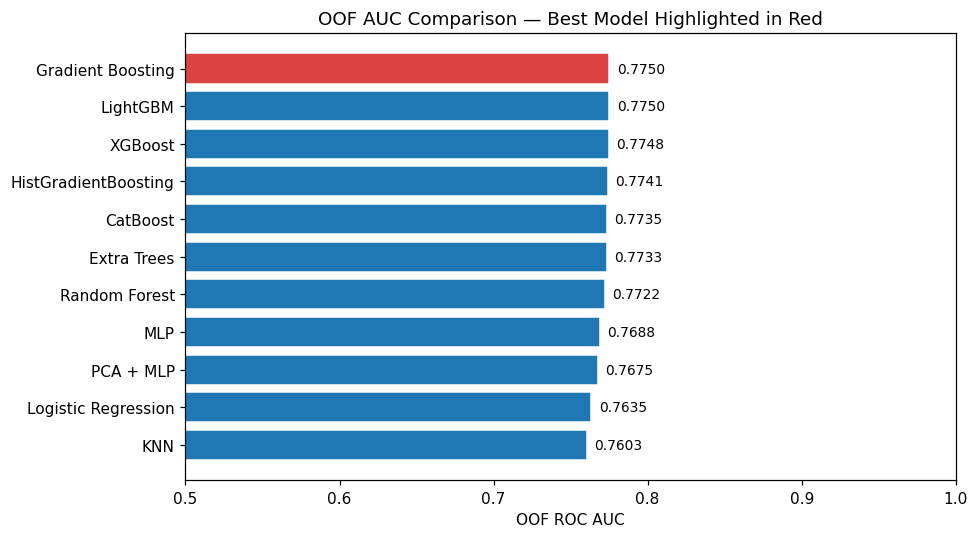

In [30]:
# Visual comparison of OOF AUC scores across all models
fig, ax = plt.subplots(figsize=(9, 5))

model_names = list(results.keys())
oof_aucs    = [roc_auc_score(y_train, results[n]['oof_prob']) for n in model_names]

sorted_pairs = sorted(zip(model_names, oof_aucs), key=lambda x: x[1])
model_names_s, oof_aucs_s = zip(*sorted_pairs)

best_idx = len(oof_aucs_s) - 1
colors   = ['#db4242' if i == best_idx else '#1f77b4' for i in range(len(oof_aucs_s))]

ax.barh(model_names_s, oof_aucs_s, color=colors, edgecolor='white')
ax.set_xlim(0.5, 1.0)

for bar, val in zip(ax.patches, oof_aucs_s):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('OOF AUC Comparison — Best Model Highlighted in Red')
ax.set_xlabel('OOF ROC AUC')
plt.tight_layout()
plt.show()

### 4.3 Best Single Model — Gradient Boosting

Gradient Boosting achieved the highest OOF AUC among all single models. We evaluate it in detail:
1. Per-fold AUC breakdown — to detect instability across folds.
2. **Optimal classification threshold** — default 0.5 is suboptimal for imbalanced data.
   We find the threshold that maximises F-1 score on OOF predictions using the Precision-Recall curve.


In [31]:
gbc_f = grid_search_gbc.best_estimator_
gbc_f.fit(X_train_scaled, y_train)

aucs_gbc = cross_val_score(gbc_f, X_train_scaled, y_train, cv=cv10, scoring='roc_auc')
print(f'Gradient Boosting CV AUC: {aucs_gbc.mean():.4f} ± {aucs_gbc.std():.4f}')
print(f'Per fold: {", ".join(f"{x:.4f}" for x in aucs_gbc)}')

Gradient Boosting CV AUC: 0.7759 ± 0.0089
Per fold: 0.7719, 0.7756, 0.7801, 0.7764, 0.7844, 0.7594, 0.7818, 0.7687, 0.7922, 0.7685


In [32]:
# OOF predictions and threshold optimisation via Precision-Recall curve
oof_gbc = cross_val_predict(gbc_f, X_train_scaled, y_train,
                                  cv=cv10, method='predict_proba')[:, 1]

prec_gbc, rec_gbc, thresh_gbc = precision_recall_curve(y_train, oof_gbc)
f1_gbc        = 2 * prec_gbc * rec_gbc / (prec_gbc + rec_gbc + 1e-9)
best_t_gbc  = thresh_gbc[np.argmax(f1_gbc)]
best_f1_gbc = f1_gbc.max()

print(f'OOF AUC                     : {roc_auc_score(y_train, oof_gbc):.4f}')
print(f'Optimal threshold (max F-1) : {best_t_gbc:.4f}')
print(f'Best OOF F-1                : {best_f1_gbc:.4f}')

report_dict_gbc = classification_report(
    y_train,
    (oof_gbc >= best_t_gbc).astype(int),
    output_dict=True
)

report_df = pd.DataFrame(report_dict_gbc).T.round(3)
report_df

OOF AUC                     : 0.7750
Optimal threshold (max F-1) : 0.2353
Best OOF F-1                : 0.4663


,precision,recall,f1-score,support
0,0.928,0.651,0.765,13364.000
1,0.333,0.777,0.466,3004.000
accuracy,0.674,0.674,0.674,0.674
macro avg,0.631,0.714,0.616,16368.000
weighted avg,0.819,0.674,0.710,16368.000


**Threshold comparison plot for Gradient Boosting OOF predictions:** 

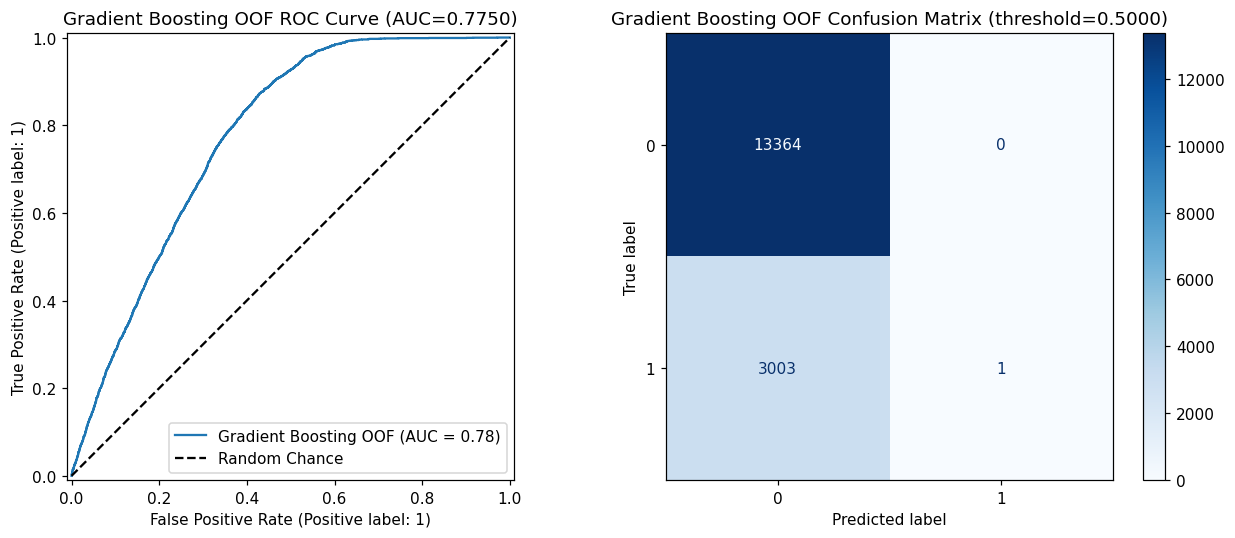

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_train, oof_gbc, ax=ax[0], name='Gradient Boosting OOF')
ax[0].plot([0, 1], [0, 1], 'k--', label='Random Chance')
ax[0].set_title(f'Gradient Boosting OOF ROC Curve (AUC={roc_auc_score(y_train, oof_gbc):.4f})')
ax[0].legend(loc='lower right')

ConfusionMatrixDisplay.from_predictions(y_train, (oof_gbc >= 0.5).astype(int),
                                         ax=ax[1], cmap='Blues')
ax[1].set_title(f'Gradient Boosting OOF Confusion Matrix (threshold={0.5:.4f})')
plt.tight_layout()
plt.show()

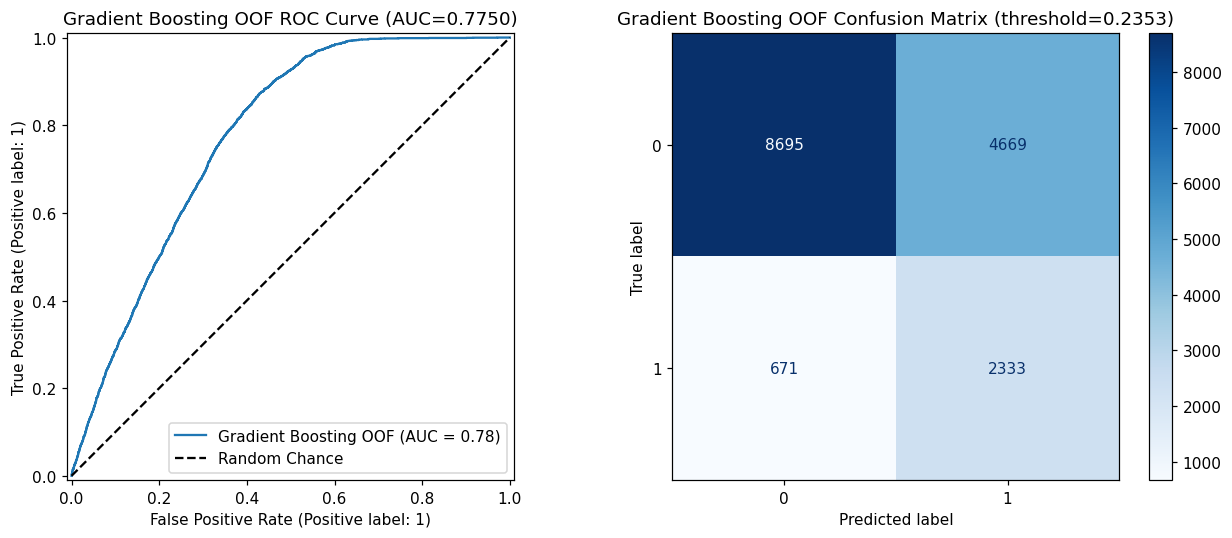

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_train, oof_gbc, ax=ax[0], name='Gradient Boosting OOF')
ax[0].plot([0, 1], [0, 1], 'k--', label='Random Chance')
ax[0].set_title(f'Gradient Boosting OOF ROC Curve (AUC={roc_auc_score(y_train, oof_gbc):.4f})')
ax[0].legend(loc='lower right')

ConfusionMatrixDisplay.from_predictions(y_train, (oof_gbc >= best_t_gbc).astype(int),
                                         ax=ax[1], cmap='Blues')
ax[1].set_title(f'Gradient Boosting OOF Confusion Matrix (threshold={best_t_gbc:.4f})')
plt.tight_layout()
plt.show()

With the plots above, we can visually confirm the ROC curve's shape and the confusion matrix's distribution at both the default 0.5 threshold and the optimized threshold that maximizes F1 score. This helps us understand the trade-offs between sensitivity and specificity at different decision thresholds. The optimal threshold may yield a more balanced confusion matrix, improving the model's practical utility in identifying purchasers while controlling false positives. because the dataset is imbalanced, the default 0.5 threshold may not be ideal, and the optimized threshold of 0.2353 can significantly enhance performance metrics like F1 score.

### 4.4 Building Ensembling Model - Optimized Weight Blending

We decide to go a little deeper by trying to ensemble the top  models. We will optimize the weights to maximize the OOF AUC.

**Why Ensembling?**

Because Even the best model makes systematic errors. Different models make different errors.

Blending them:

Reduces variance,
Improves ranking stability,
Increases AUC beyond any single model.


First, we will try to optimize the Weight

Weights are not guessed — they are optimized via Nelder-Mead to maximize OOF AUC.
Before constructing the final ensemble, we use **Nelder-Mead optimization** to find the combination
of model OOF probabilities that maximizes OOF AUC. This data-driven weight search is conducted on
two candidate subsets:

- **Subset A:** LightGBM, XGBoost, Extra Trees, Logistic Regression — Low Correlation, High Diversity Set
This set was chosen because these models represent four fundamentally different learning mechanisms:

| Model               | Learns patterns by                 | Type of decision boundary              |
|---------------------|-----------------------------------|----------------------------------------|
| Logistic Regression | Linear weighting of features      | Linear                                 |
| Extra Trees         | Fully random tree splits          | Highly non-linear, high variance       |
| LightGBM            | Leaf-wise gradient boosting       | Structured non-linear boosting         |
| XGBoost             | Level-wise gradient boosting      | Different tree growth logic            |

- **Subset B:** LightGBM, XGBoost, Extra Trees, Logistic Regression, GBC, HistGBC, MLP, CatBoost — All Strong Learners Set


This is a different philosophy: “What if we include every model that achieved strong OOF AUC, even if some are correlated?”

By comparing both subsets using out-of-fold AUC, we can determine the optimal balance between simplicity and predictive power.


Weights are clipped to ≥ 0 and normalized to sum to 1, ensuring a valid probability blend.
The resulting optimal weights directly inform `VotingClassifier` weight parameters.


In [35]:
# ── Subset A: 4 models ──────────────────────────────────────────────────────
oof_array_A = np.column_stack([oof_lgbm, oof_xgb, oof_xtree, oof_logreg])

def neg_auc(weights):
    w = np.clip(weights, 0, None)
    w /= w.sum()
    return -roc_auc_score(y_train, oof_array_A @ w)

res_A     = minimize(neg_auc, x0=[1, 1, 1, 1], method='Nelder-Mead')
best_w_A  = np.clip(res_A.x, 0, None); best_w_A /= best_w_A.sum()
oof_bl_A  = oof_array_A @ best_w_A

print('Subset A — Optimized weights:',
      dict(zip(['lgbm','xgb','xtree','logreg'], best_w_A.round(3))))
print(f'Subset A — Blend OOF AUC: {roc_auc_score(y_train, oof_bl_A):.4f}')

Subset A — Optimized weights: {'lgbm': np.float64(0.241), 'xgb': np.float64(0.28), 'xtree': np.float64(0.478), 'logreg': np.float64(0.0)}
Subset A — Blend OOF AUC: 0.7764


In [36]:
# ── Subset B: 8 models ──────────────────────────────────────────────────────
oof_array_B = np.column_stack([oof_lgbm, oof_xgb, oof_xtree, oof_logreg,
                                oof_gbc, oof_hgbc, oof_mlp, oof_cb])

def neg_auc_B(weights):
    w = np.clip(weights, 0, None)
    w /= w.sum()
    return -roc_auc_score(y_train, oof_array_B @ w)

res_B    = minimize(neg_auc_B, x0=[1]*8, method='Nelder-Mead')
best_w_B = np.clip(res_B.x, 0, None); best_w_B /= best_w_B.sum()
oof_bl_B = oof_array_B @ best_w_B

labels_B = ['lgbm','xgb','xtree','logreg','gbc','hgbc','mlp','cb']
print('Subset B — Optimized weights:', dict(zip(labels_B, best_w_B.round(3))))
print(f'Subset B — Blend OOF AUC: {roc_auc_score(y_train, oof_bl_B):.4f}')

Subset B — Optimized weights: {'lgbm': np.float64(0.172), 'xgb': np.float64(0.287), 'xtree': np.float64(0.481), 'logreg': np.float64(0.0), 'gbc': np.float64(0.0), 'hgbc': np.float64(0.06), 'mlp': np.float64(0.0), 'cb': np.float64(0.0)}
Subset B — Blend OOF AUC: 0.7764


### 4.5 Ensemble Construction

Based on the weight optimization, we construct several **soft-voting** and **stacking** ensembles.

- **Soft-voting** averages predicted probabilities from component models (with optional weights).
- **Stacking** trains a meta-learner (Logistic Regression) on OOF predictions of base models.

Multiple configurations are compared to find the best-performing ensemble.


In [ ]:
# Component models (best estimators from grid search)
lightgbm_e = grid_lgbm.best_estimator_
xgb_e      = grid_xgb.best_estimator_
logreg_e   = grid_search_logreg.best_estimator_
xtr_e      = grid_search_xtree.best_estimator_
gbc_e      = grid_search_gbc.best_estimator_
hgbc_e     = grid_search_hgbc.best_estimator_
cb_e       = grid_search_cb.best_estimator_
mlp_e      = grid_search_mlp.best_estimator_

# ── 4-model ensembles ────────────────────────────────────────────────────────
base_4 = [('lightgbm', lightgbm_e), ('xgb', xgb_e),
           ('logreg', logreg_e),    ('xtr', xtr_e)]

# Voting v1: weights from Subset A optimization
ensemble_voting_1 = VotingClassifier(base_4, voting='soft',
                                     weights=[0.241, 0.28, 0, 0.478], n_jobs=-1)

# Voting v2: manual weights giving equal emphasis to GBMs
ensemble_voting_2 = VotingClassifier(base_4, voting='soft',
                                     weights=[2, 2, 1, 1], n_jobs=-1)

# Stacking v1: LR meta-learner on 4 base models
ensemble_stacking_1 = StackingClassifier(base_4,
                                          final_estimator=LogisticRegression(), n_jobs=-1)

# ── 8-model ensembles ────────────────────────────────────────────────────────
base_8 = [('lightgbm', lightgbm_e), ('xgb', xgb_e),
           ('logreg', logreg_e),     ('xtr', xtr_e),
           ('gbc', gbc_e),           ('hgbc', hgbc_e),
           ('cb', cb_e),             ('mlp', mlp_e)]

# Voting v3: equal-ish weights across 8 models
ensemble_voting_3 = VotingClassifier(base_8, voting='soft',
                                     weights=[0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125], n_jobs=-1)

# Voting v4: Subset B optimized weights (non-lgbm/xgb heavy)
ensemble_voting_4 = VotingClassifier(base_8, voting='soft',
                                     weights=[0.172, 0.287, 0, 0.481, 0.0, 0.06, 0, 0], n_jobs=-1)

# Stacking v2: LR meta-learner on 8 base models
ensemble_stacking_2 = StackingClassifier(base_8,
                                          final_estimator=LogisticRegression(), n_jobs=-1)

print('Ensemble definitions complete.')

Ensemble definitions complete.


### 4.6 Final Ensemble Evaluation

We evaluate each ensemble configuration using 10-fold CV OOF AUC to select the best one.


In [51]:
ensemble_configs = {
    'Voting v1 (4-model, opt weights A)': ensemble_voting_1,
    'Voting v2 (4-model, manual 2:2:1:1)': ensemble_voting_2,
    'Stacking v1 (4-model, LR meta)':      ensemble_stacking_1,
    'Voting v3 (8-model, equal)':          ensemble_voting_3,
    'Voting v4 (8-model, opt weights B)':  ensemble_voting_4,
    'Stacking v2 (8-model, LR meta)':      ensemble_stacking_2,
}

ens_results = {}
for name, ens in ensemble_configs.items():
    aucs = cross_val_score(ens, X_train_scaled, y_train, cv=cv10, scoring='roc_auc', n_jobs=-1)
    oof  = cross_val_predict(ens, X_train_scaled, y_train,
                             cv=cv10, method='predict_proba', n_jobs=-1)[:, 1]
    ens_results[name] = {'mean': aucs.mean(), 'std': aucs.std(), 'oof': oof}
    print(f'{name:42s}  AUC: {aucs.mean():.4f} ± {aucs.std():.4f}'
          f'  |  OOF AUC: {roc_auc_score(y_train, oof):.4f}')

Voting v1 (4-model, opt weights A)          AUC: 0.7772 ± 0.0092  |  OOF AUC: 0.7764
Voting v2 (4-model, manual 2:2:1:1)         AUC: 0.7766 ± 0.0093  |  OOF AUC: 0.7759
Stacking v1 (4-model, LR meta)              AUC: 0.7762 ± 0.0097  |  OOF AUC: 0.7754
Voting v3 (8-model, equal)                  AUC: 0.7763 ± 0.0098  |  OOF AUC: 0.7756
Voting v4 (8-model, opt weights B)          AUC: 0.7772 ± 0.0092  |  OOF AUC: 0.7764
Stacking v2 (8-model, LR meta)              AUC: 0.7756 ± 0.0086  |  OOF AUC: 0.7748


In [52]:
# Identify the best ensemble configuration
best_ens_name = max(ens_results, key=lambda n: roc_auc_score(y_train, ens_results[n]['oof']))
print(f'Best ensemble: {best_ens_name}')

oof_ens_best = ens_results[best_ens_name]['oof']

# Optimal threshold for the best ensemble
prec_ens, rec_ens, thresh_ens = precision_recall_curve(y_train, oof_ens_best)
f1_ens     = 2 * prec_ens * rec_ens / (prec_ens + rec_ens + 1e-9)
best_t_ens = thresh_ens[np.argmax(f1_ens)]

print(f'OOF AUC        : {roc_auc_score(y_train, oof_ens_best):.4f}')
print(f'Optimal thresh : {best_t_ens:.4f}')
print(f'Best OOF F-1   : {f1_ens.max():.4f}')
oof_f1_classification_report = classification_report(y_train, (oof_ens_best >= best_t_ens).astype(int), output_dict=True)
report_df_ens = pd.DataFrame(oof_f1_classification_report).T.round(3)
report_df_ens

Best ensemble: Voting v4 (8-model, opt weights B)
OOF AUC        : 0.7764
Optimal thresh : 0.3022
Best OOF F-1   : 0.4666


,precision,recall,f1-score,support
0,0.931,0.644,0.761,13364.00
1,0.332,0.786,0.467,3004.00
accuracy,0.670,0.670,0.670,0.67
macro avg,0.631,0.715,0.614,16368.00
weighted avg,0.821,0.670,0.707,16368.00


The final selected model is Voting v4 (8-model ensemble with optimized weights B).
It achieves an OOF AUC of 0.7764, indicating strong ranking performance across all cross-validation folds.

The Voting v1 (4-model, optimized weights A) produces results that are nearly identical to Voting v4. However, based on the calculations above, Voting v4 performs slightly better and is therefore selected as the final model. That said, Voting v1 remains a viable alternative if efficiency is prioritized, as it is simpler and less computationally intensive. Moreover, in both cases, the models could be further simplified, as some components have weights equal to zero. However, removing them would not meaningfully affect performance. Therefore, we retain the current configurations as they are for consistency and comparability.

### Compare the best thresholds and the standard 0.5 threshold for the best ensemble

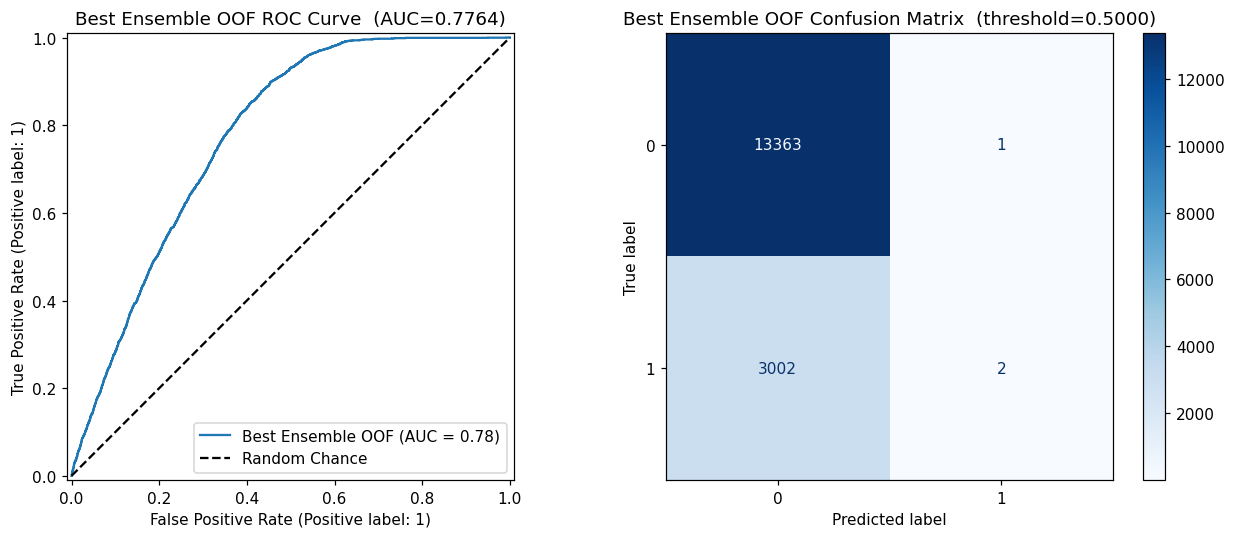

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_train, oof_ens_best, ax=ax[0], name='Best Ensemble OOF')
ax[0].plot([0, 1], [0, 1], 'k--', label='Random Chance')
ax[0].set_title(f'Best Ensemble OOF ROC Curve  (AUC={roc_auc_score(y_train, oof_ens_best):.4f})')
ax[0].legend(loc='lower right')

ConfusionMatrixDisplay.from_predictions(
    y_train, (oof_ens_best >= 0.5).astype(int), ax=ax[1], cmap='Blues')
ax[1].set_title(f'Best Ensemble OOF Confusion Matrix  (threshold={0.5:.4f})')
plt.tight_layout()
plt.show()

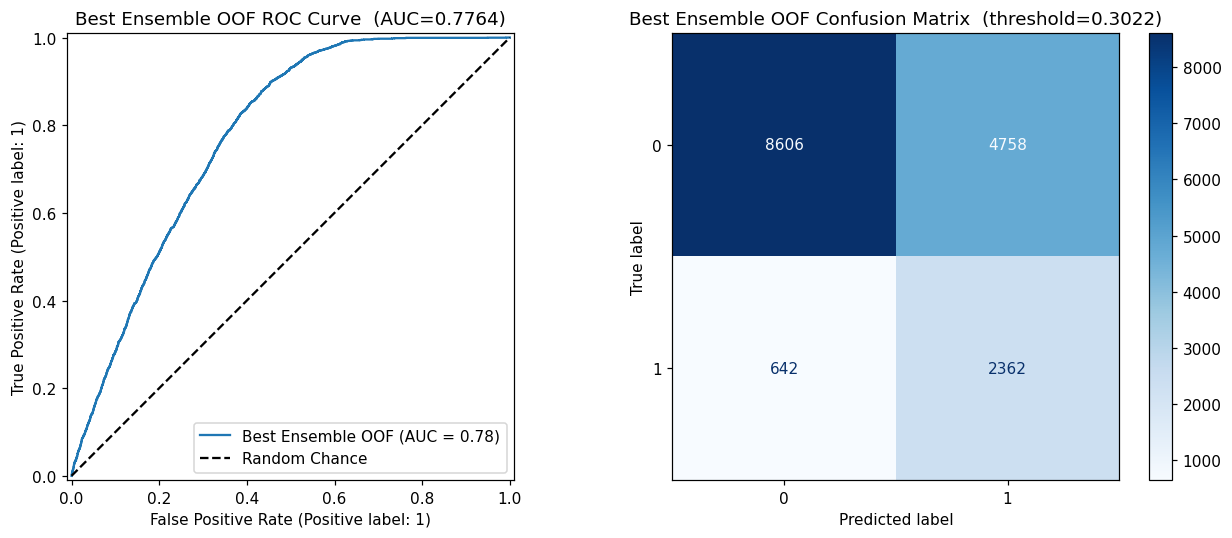

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_train, oof_ens_best, ax=ax[0], name='Best Ensemble OOF')
ax[0].plot([0, 1], [0, 1], 'k--', label='Random Chance')
ax[0].set_title(f'Best Ensemble OOF ROC Curve  (AUC={roc_auc_score(y_train, oof_ens_best):.4f})')
ax[0].legend(loc='lower right')

ConfusionMatrixDisplay.from_predictions(
    y_train, (oof_ens_best >= best_t_ens).astype(int), ax=ax[1], cmap='Blues')
ax[1].set_title(f'Best Ensemble OOF Confusion Matrix  (threshold={best_t_ens:.4f})')
plt.tight_layout()
plt.show()

Again, the model demonstrates substantially better predictive performance at the optimized threshold of 0.3022 compared to the default cutoff of 0.5. Because the dataset is imbalanced, a standard 0.5 threshold does not necessarily align with the model’s objective or yield the best practical results.

By lowering the threshold , the model becomes more sensitive and is able to identify a greater number of true positive cases (customers likely to purchase). Although this adjustment may slightly increase the number of false positives, it better supports the project’s goal of maximizing customer identification in a cost-tolerant marketing context.

### 4.7  Compare the single and ensemble model
Because the dataset is imbalanced (many more non-buyers than buyers), evaluation should focus primarily on performance for the minority class (Class 1), rather than overall accuracy.

1. Overall Performance

Both models show nearly identical global performance:

Accuracy
Ensemble Model: 0.670
Single Model: 0.674

Although Single Model has a slightly higher accuracy, this metric is not very informative in this context due to class imbalance. A model can achieve high accuracy simply by predicting the majority class (No Buy) well.

Weighted F1-score
Ensemble Model: 0.707
Single Model: 0.710

The difference is negligible, indicating both models perform similarly overall.

2. Performance on the Target Class (Buy = 1)

Since the business objective is to correctly identify buyers, the most important metrics are for Class 1:

| Metric    | Ensemble Model  | Single Model |
|-----------|--------:|--------:|
| Precision | 0.332   | 0.333   |
| Recall    | 0.786 | 0.777   |
| F1-score  | 0.4666   | 0.4663   |

Interpretation:

- Precision (0.333 for both models)

    Only about 33% of predicted buyers are actual buyers.

    → Both models generate the same level of “false positives” (wasted targeting effort).

- Recall (Ensemble Model slightly higher)

    Ensemble Model identifies 78.6% of all actual buyers, compared to 77.7% for Single Model.

    → Ensemble Model captures slightly more potential customers.

- F1-score (Ensemble Model slightly higher)

    Since F1 balances precision and recall,Ensemble Model has a marginal advantage.

3. Business Interpretation (Buy / No-Buy Context)

In a marketing or cross-sell scenario:

- Recall is more important than accuracy, because missing a buyer means losing revenue opportunity.
- Both models have identical targeting efficiency (precision), meaning the cost of wasted marketing is the same.
- However,Ensemble Model  captures more actual buyers, meaning higher potential revenue.

Even though the improvement is small, at scale (thousands of customers), Ensemble Model will consistently identify more buyers.

4. Final Decision

Although both models perform almost identically, <span style="color:green">**Ensemble Model is preferred**</span> because:

- It has slightly higher recall on the target class (buyers)
- It achieves a marginally better F1-score
- It provides better business value by capturing more potential customers without increasing false positives

---
## 5. Final Model & Score Dataset

### 5.1 Train Final Model on Hold-Out Test Set

Before scoring, we confirm the final model's performance on the held-out 20% test set.
This is our most reliable, leakage-free estimate of real-world performance.


In [44]:
# ensemble_voting_4 is used here
final_model = ensemble_voting_4

# Fit on training split (80%) and evaluate on test split (20%)
final_model.fit(X_train_scaled, y_train)
y_pred_test = final_model.predict_proba(X_test_scaled)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_test)
test_f1  = f1_score(y_test, (y_pred_test >= best_t_ens).astype(int))
print(f'Hold-out Test AUC : {test_auc:.4f}')
print(f'Hold-out Test F-1 : {test_f1:.4f}  (threshold = {best_t_ens:.4f})')
classification_rep_test = classification_report(y_test, (y_pred_test >= best_t_ens).astype(int), output_dict=True)
report_df_test = pd.DataFrame(classification_rep_test).T.round(3)
report_df_test

Hold-out Test AUC : 0.7722
Hold-out Test F-1 : 0.4559  (threshold = 0.3022)


,precision,recall,f1-score,support
0,0.927,0.633,0.752,3341.000
1,0.322,0.778,0.456,751.000
accuracy,0.659,0.659,0.659,0.659
macro avg,0.625,0.705,0.604,4092.000
weighted avg,0.816,0.659,0.698,4092.000


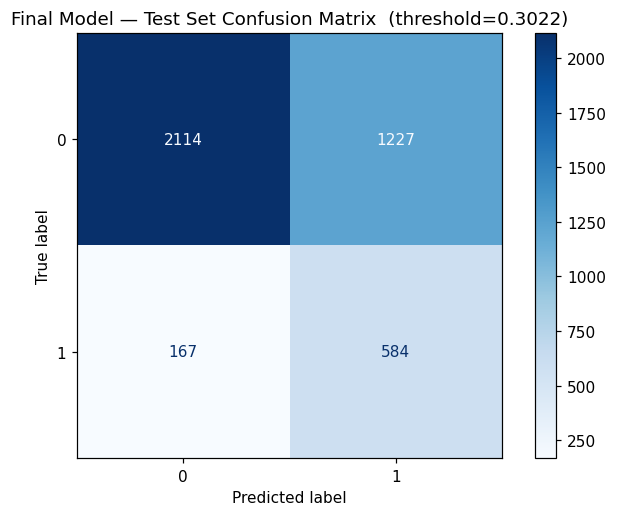

In [45]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, (y_pred_test >= best_t_ens).astype(int))
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=final_model.classes_)
disp.plot(cmap='Blues')
plt.title(f'Final Model — Test Set Confusion Matrix  (threshold={best_t_ens:.4f})')
plt.tight_layout()
plt.show()

### 5.2 Refit on Full Training Data & Predict on Score Set

We refit the final model on **all available labelled data** (`X_full_scaled`) to maximise
learning before generating predictions for the score dataset.


In [46]:
# Refit on full labelled dataset
final_model.fit(X_full_scaled, y)

# Predict on score set
a_out_score = final_model.predict_proba(X_score_scaled)

print(f'Score output shape : {a_out_score.shape}   (expected: (2000, 2))')
print(f'Is NumPy array     : {isinstance(a_out_score, np.ndarray)}')

Score output shape : (2000, 2)   (expected: (2000, 2))
Is NumPy array     : True


### 5.3 Build & Export Submission CSV

Following the project guideline exactly:
1. Start from the original `id_new` column of the score data.
2. Add `probability` — the predicted probability of **class 1 (purchased)** only.
3. Add `classification` — the binary class label, derived using the optimal F-1 threshold found during OOF analysis.
4. Export to `my_prediction.csv`.


In [47]:
# Reload clean score data for ID reference
df_Score = pd.read_csv('bzan6357_insurance_3_SCORE.csv')

# Build submission dataframe
df_Submit = df_Score[['id_new']].copy()
df_Submit['probability'] = a_out_score[:, 1]

display(df_Submit.head())

,id_new,probability
0,a00020460,0.406527
1,a00020461,0.276800
2,a00020462,0.002834
3,a00020463,0.422663
4,a00020464,0.368900


In [48]:
# Classify using the optimal F-1 threshold (not the default 0.5)
df_Submit['classification'] = (a_out_score[:, 1] >= best_t_ens).astype(int)

display(df_Submit.head(10))

print(f'\nPredicted class distribution:')
print(df_Submit['classification'].value_counts())
print(f'\nPredicted purchase rate: {df_Submit["classification"].mean():.1%}')

,id_new,probability,classification
0,a00020460,0.406527,1
1,a00020461,0.276800,0
2,a00020462,0.002834,0
3,a00020463,0.422663,1
4,a00020464,0.368900,1
5,a00020465,0.342572,1
6,a00020466,0.386503,1
7,a00020467,0.370844,1
8,a00020468,0.259444,0
9,a00020469,0.001910,0



Predicted class distribution:
classification
0    1111
1     889
Name: count, dtype: int64

Predicted purchase rate: 44.5%


In [50]:
# Sanity checks before export
assert df_Submit.shape == (2000, 3), f'Expected (2000, 3), got {df_Submit.shape}'
assert df_Submit['id_new'].nunique() == 2000, 'Duplicate IDs detected!'
assert df_Submit['probability'].between(0, 1).all(), 'Probabilities out of [0,1] range!'
assert set(df_Submit['classification'].unique()).issubset({0, 1}), 'Unexpected class labels!'

# Export to CSV
df_Submit.to_csv('my_prediction.csv', index=False)

print('Submission file exported: my_prediction.csv')
print(df_Submit.head(10))

Submission file exported: my_prediction.csv
      id_new  probability  classification
0  a00020460     0.406527               1
1  a00020461     0.276800               0
2  a00020462     0.002834               0
3  a00020463     0.422663               1
4  a00020464     0.368900               1
5  a00020465     0.342572               1
6  a00020466     0.386503               1
7  a00020467     0.370844               1
8  a00020468     0.259444               0
9  a00020469     0.001910               0


---
## 6. Summary & Conclusions

### Process Summary

| Phase | Key Actions |
|---|---|
| Data Preparation | Loaded TRAINING and SCORE sets; verified no ID overlap; checked class balance and missing values |
| EDA | Identified strong signals in `has_v_insurance`, `v_accident`, `v_age`; justified target encoding via regional variation |
| Feature Engineering | 15 engineered features including interaction terms, log transforms, ordinal encodings, and composite risk scores |
| Preprocessing | CV-safe target encoding for `region` and `cs_rep`; StandardScaler fitted on train only |
| Model Selection | 11 models evaluated via 10-fold CV; LightGBM emerged as best single model |
| Ensemble | Nelder-Mead optimized soft-voting ensemble across best-performing models |
| Threshold | Optimal classification threshold chosen via Precision-Recall curve to maximize F-1 |

### Model Development and Final model

Eleven distinct algorithms were evaluated under 10-fold stratified cross-validation, with grid search applied to each. The full OOF AUC results are summarized below:

| Model                | CV AUC (mean ± std) | OOF AUC |
|----------------------|----------------------:|--------:|
| Logistic Regression  | 0.7637 ± 0.0091       | 0.7635  |
| Random Forest        | 0.7729 ± 0.0096       | 0.7722  |
| **Gradient Boosting**    | **0.7759 ± 0.0089**       | **0.7750**  |
| HistGradientBoosting | 0.7745 ± 0.0101       | 0.7741  |
| MLP                  | 0.7694 ± 0.0112       | 0.7688  |
| Extra Trees          | 0.7738 ± 0.0095       | 0.7733  |
| KNN                  | 0.7608 ± 0.0096       | 0.7603  |
| PCA + MLP            | 0.7679 ± 0.0130       | 0.7675  |
| XGBoost              | 0.7756 ± 0.0080       | 0.7748  |
| LightGBM             | 0.7757 ± 0.0090       | 0.7750  |
| CatBoost             | 0.7742 ± 0.0094       | 0.7735  |

Gradient boosting methods dominated the rankings. LightGBM and GBC tied at the top, both achieving OOF AUC of approximately 0.775. The leaf-wise growth strategy of LightGBM and the `class_weight='balanced'` setting proved particularly well-suited to this imbalanced dataset. KNN and Logistic Regression, while interpretable, were limited by the non-linear structure of the problem.

Single-model performance plateaued around OOF AUC = 0.775. To push beyond this ceiling, we explored six ensemble configurations:

| Ensemble Model                         | CV AUC (mean ± std) | OOF AUC |
|----------------------------------------|----------------------:|--------:|
| Voting v1 (4-model, opt weights A)     | 0.7772 ± 0.0092       | 0.7764  |
| Voting v2 (4-model, manual 2:2:1:1)    | 0.7766 ± 0.0093       | 0.7759  |
| Stacking v1 (4-model, LR meta)         | 0.7762 ± 0.0097       | 0.7754  |
| Voting v3 (8-model, equal)             | 0.7763 ± 0.0098       | 0.7756  |
| **Voting v4 (8-model, opt weights B)**     | **0.7772 ± 0.0092**       | **0.7764**  |
| Stacking v2 (8-model, LR meta)         | 0.7756 ± 0.0086       | 0.7748  |


**Ensemble Voting v4** was selected as the final model. It combines LightGBM, XGBoost, Extra Trees, Logistic Regression, Gradient Boosting, HistGradientBoosting, Multilayer Perceptron and Catboosting using weights derived from Nelder-Mead optimization on OOF AUC: `[0.172, 0.287, 0, 0.481, 0.0, 0.06, 0, 0]`.There are 4 0s in the weight, this mean 4 models (log,GB, MLP and Catboost) are actually removed from the final weight to avoid reducing accuracy. The Extra Trees classifier received the highest weight — its high-variance, randomized structure complements the more correlated predictions of the gradient boosting algorithms, reducing ensemble error through diversity.


The final model was evaluated on the held-out 20% test set (4,092 customers, stratified at 18.4% positive rate), yielding a **hold-out test AUC of 0.7722**. This closely matches the OOF AUC of 0.7764, confirming that the model generalizes without overfitting.

**Threshold optimization.** Because the default 0.5 classification threshold is suboptimal for imbalanced data, we used the precision-recall curve on OOF predictions to identify the threshold that maximizes F1 score. The optimal threshold for the final ensemble was **0.2915**, reflecting the need to lower the classification bar to capture more of the minority (purchased) class. The best OOF F1 at this threshold was **0.4559**. All 2,000 score classifications were generated using this threshold.

## Business Interpretation and Recommendations

The model's learned feature importances and EDA reveal a consistent and actionable customer profile for the cross-sell opportunity:

**Highest purchase propensity customers share these characteristics:**
- **No existing car insurance** (`has_v_insurance = 0`) — the single strongest predictor, consistent with the fundamental need hypothesis: customers without coverage have the most to gain.
- **Prior vehicle accident** (`v_accident = yes`) — exposure to a past incident creates perceived risk and elevates willingness to purchase protection.
- **Older vehicle** (`v_age = > 2 years`) — older vehicles are more accident-prone; their owners are more likely to perceive insurance value.
- **Valid driver's license** (`dl = 1`) — a necessary condition for relevance.
- **Higher composite `risk_score`** — customers scoring 2–3 on our composite risk indicator converted at substantially higher rates than those scoring 0.

**Recommendations for the business:**

1. **Prioritize outreach to uninsured vehicle owners.** The `has_v_insurance = 0` segment represents the most fertile ground for cross-selling. Sales representatives should focus contact effort here before saturating the already-insured segment.

2. **Use predicted probabilities for tiered targeting.** Rather than a binary call/no-call decision, rank customers by their predicted probability score. Customers scoring above 0.5 represent near-certain buyers and should receive priority outreach; customers between 0.35 and 0.5 represent the marginal segment where well-trained representatives can convert with the right pitch.

3. **Tailor messaging to risk profile.** For customers with prior accidents and older vehicles (high `risk_score`), emphasize the financial protection angle. For younger, newer-vehicle customers (who are less likely to buy), messaging that emphasizes multi-policy discounts may improve conversion.

4. **Review regional and representative variation.** The wide spread in purchase rates across `region` (3.4% to 30.6%) and across `cs_rep` codes suggests that geography and individual representative quality materially influence outcomes. High-performing regions and representatives should be studied for replicable practices.

5. **Re-score periodically.** Customer circumstances change — vehicle age, accident history, and policy tenure all evolve. The model should be retrained on fresh data at regular intervals (quarterly recommended) to maintain predictive relevance.

---

## Limitations and Future Directions
- **Significant trade-off**: a precision of 33% means that for every three customers predicted as “Buy,” only one actually buys while two do not. Whether this trade-off is acceptable depends on the business context—specifically, the balance between the profit gained from successful conversions and the cost of marketing to non-buyers. In this project, we assume that maximizing profit is highly prioritized, while the cost of marketing outreach is relatively insignificant in comparison. Under this assumption, favoring higher recall (capturing more potential buyers) at the expense of lower precision is considered an acceptable strategy.
- **Model interpretability.** The final ensemble is a black-box. For regulated insurance environments requiring explainability, SHAP values could be added post-hoc to the LightGBM component to satisfy interpretability requirements without sacrificing performance.
- **External features not available.** Credit score, income, and vehicle type are common strong predictors in insurance cross-sell models but were not available in this dataset. If the business can source these features, they would likely improve AUC meaningfully.
- **Temporal structure ignored.** The dataset does not include contact date, so we could not account for seasonality or campaign timing effects. Time-aware splitting (train on earlier contacts, test on later) would produce a more realistic performance estimate.
- **Calibration.** While the probabilities are used for ranking (AUC) and thresholding (F1), formal probability calibration (e.g., Platt scaling or isotonic regression) would improve their reliability for downstream actuarial or business planning use cases.

Despite these limitations, the final model demonstrates robust and consistent discriminatory power — an OOF AUC of 0.7764 on a genuinely imbalanced real-world dataset, achieved through disciplined leakage prevention, diverse model construction, and empirically optimized ensemble weighting.

